In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("engineered_nyc_2.csv")
df.head()

,Fiscal_Year,Borough,Award,Council_District_num,Sector,Category
0,2019,X,250000,16.0,Housing & Dev,Community/Housing
1,2019,K,3640000,37.0,Health & Human Svcs,"Education, Infrastructure/Renovation"
2,2019,M,425000,5.0,Education,"Education, Infrastructure/Renovation"
3,2019,M,100000,5.0,Education,"Education, Infrastructure/Renovation, Parks & ..."
4,2019,M,35000,5.0,Education,"Education, Infrastructure/Renovation, Technology"


In [25]:
df.isna().sum()

Fiscal_Year              0
Borough                  0
Award                    0
Council_District_num    26
Sector                   0
Category                 0
dtype: int64

In [26]:
df["Council_District_num"] = df["Council_District_num"].fillna("No_District")
#check
df.isna().sum()

Fiscal_Year             0
Borough                 0
Award                   0
Council_District_num    0
Sector                  0
Category                0
dtype: int64

In [27]:
df["log_Awards"] = np.log(df["Award"])
df.head()

,Fiscal_Year,Borough,Award,Council_District_num,Sector,Category,log_Awards
0,2019,X,250000,16.0,Housing & Dev,Community/Housing,12.429216
1,2019,K,3640000,37.0,Health & Human Svcs,"Education, Infrastructure/Renovation",15.107494
2,2019,M,425000,5.0,Education,"Education, Infrastructure/Renovation",12.959844
3,2019,M,100000,5.0,Education,"Education, Infrastructure/Renovation, Parks & ...",11.512925
4,2019,M,35000,5.0,Education,"Education, Infrastructure/Renovation, Technology",10.463103


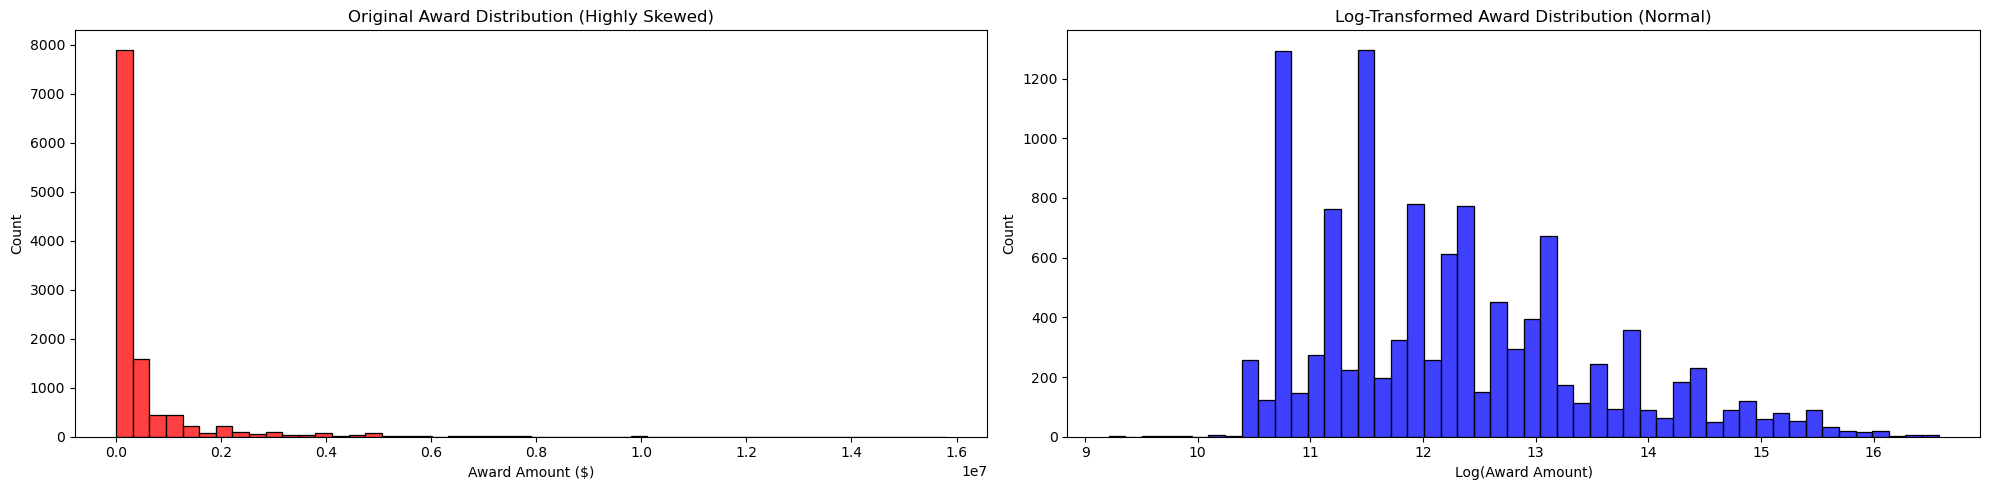

In [28]:
#plotting before vs after log transformation

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Plot 1: Original Skewed Data
sns.histplot(df['Award'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Original Award Distribution (Highly Skewed)')
axes[0].set_xlabel('Award Amount ($)')

# Plot 2: Log-Transformed Data
sns.histplot(df['log_Awards'], bins=50, ax=axes[1], color='blue')
axes[1].set_title('Log-Transformed Award Distribution (Normal)')
axes[1].set_xlabel('Log(Award Amount)')

plt.tight_layout()
plt.show()

In [29]:
df['Fiscal_Year'].unique()

array([2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029],
      dtype=int64)

In [30]:
# Removing rows with years 2027 to 2029
df = df[~df['Fiscal_Year'].isin([2027, 2028, 2029])]

In [31]:
df['Fiscal_Year'].unique()

array([2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], dtype=int64)

In [32]:
# df.to_csv('engineered_withlogs.csv', index=False)

==========

Train Test Splitting - splitting the data into 5 features to be used for all models

==========

In [33]:
# 1. Splitting
X = df.drop(['Award', 'log_Awards'], axis=1)
y = df['log_Awards']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Target Encoding
# We use the raw Award from training to find the medians
train_temp = X_train.copy()
train_temp['Award'] = np.expm1(y_train) # Get original award back for medians

year_med = train_temp.groupby('Fiscal_Year')['Award'].median()
borough_med = train_temp.groupby('Borough')['Award'].median()
sector_med = train_temp.groupby('Sector')['Award'].median()
category_med = train_temp.groupby('Category')['Award'].median()

# Map and Fill
X_train['Year_Score'] = X_train['Fiscal_Year'].map(year_med).fillna(train_temp['Award'].median())
X_test['Year_Score'] = X_test['Fiscal_Year'].map(year_med).fillna(train_temp['Award'].median())

X_train['Borough_Score'] = X_train['Borough'].map(borough_med).fillna(train_temp['Award'].median())
X_test['Borough_Score'] = X_test['Borough'].map(borough_med).fillna(train_temp['Award'].median())

X_train['Sector_Score'] = X_train['Sector'].map(sector_med).fillna(train_temp['Award'].median())
X_test['Sector_Score'] = X_test['Sector'].map(sector_med).fillna(train_temp['Award'].median())

X_train['Category_Score'] = X_train['Category'].map(category_med).fillna(train_temp['Award'].median())
X_test['Category_Score'] = X_test['Category'].map(category_med).fillna(train_temp['Award'].median())


# Dropping unnecessary columns
to_drop = ['Borough', 'Council_District_num', 'Category', 'Sector']
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

# Ensure both have same columns (if a borough was missing in test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [34]:
#Scaling each column in X_train and X_test
# 1. Initialize the scaler and tell it to output Pandas DataFrames
scaler = StandardScaler().set_output(transform="pandas")
scaler_y = StandardScaler()

# 2. Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the test data
X_test_scaled = scaler.transform(X_test)

# 4. Reshaping log_awards to work with Scratch
X_train_scaled_reshaped = X_train_scaled.values.reshape(-1,1)
X_test_scaled_reshaped = X_test_scaled.values.reshape(-1,1)
y_train_reshaped = y_train.values.reshape(-1,1)
y_test_reshaped = y_test.values.reshape(-1,1)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped)
y_test_scaled = scaler_y.transform(y_test_reshaped)

In [35]:
# # 1. Check for missing or infinite values
# print("Total NaNs in X_train_scaled:", X_train_scaled.isna().sum().sum())
# print("Total NaNs in y_train:", np.isnan(y_train_reshaped).sum())

# # 2. Check for infinite values (happens if standard deviation was 0)
# print("Total Infs in X_train_scaled:", np.isinf(X_train_scaled.values).sum())

# # 3. Check shapes (they MUST have the exact same number of rows)
# print("X_train shape:", X_train_scaled.shape)
# print("y_train shape:", y_train_reshaped.shape)

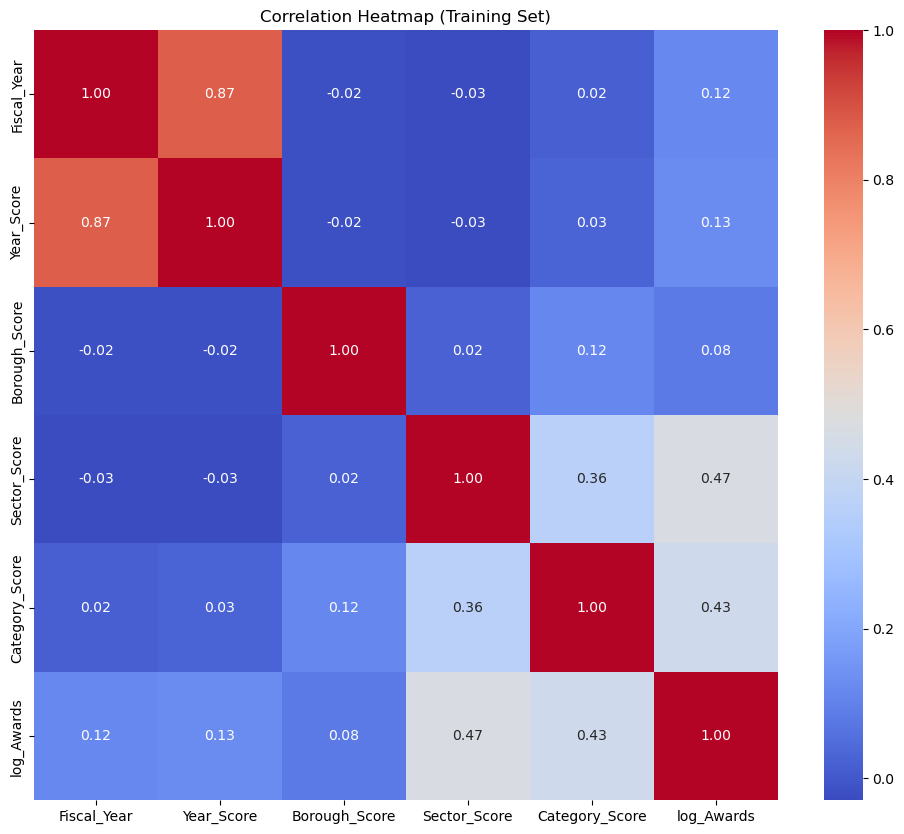

In [36]:
#correlation graph between X_train and y_train
# 1. Combine X_train and y_train into one DataFrame
# We do this to see the correlation between features AND the target
train_df = pd.concat([X_train, y_train], axis=1)

# 2. Calculate the correlation matrix
corr_matrix = train_df.corr()

# 3. Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Training Set)")
plt.show()

In [ ]:
#correlation graph between X_train and y_train
# 1. Combine X_train and y_train into one DataFrame
# We do this to see the correlation between features AND the target
train_df = pd.concat([X_train, y_train], axis=1)

# 2. Calculate the correlation matrix
corr_matrix = train_df.corr()

# 3. Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Training Set)")
plt.show()

==========

Simple Linear Regression

==========

In [37]:
# # LinearRegression Class from scratch
# from regression_classes import LinearRegressionScratch

In [38]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        m, n_features = X.shape
        
        # 1. Initialize weights to zeros
        self.coef_ = np.zeros((n_features, 1))
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            # Calculate the predictions
            y_pred = self.predict(X)

            # 2. Compute the RESIDUALS (Derivative base)
            residuals = y_pred - y  

            # 3. Calculate the gradients correctly
            # Derivative of MSE with respect to intercept
            intercept_gradient = (2/m) * np.sum(residuals)
            
            # Derivative of MSE with respect to coefficients
            coef_gradient = (2/m) * np.dot(X.T, residuals)

            # 4. Update the parameters
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient


    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_
    
    def R_squared(self, y_true, y_pred):
        SSres = np.sum((y_true - y_pred)**2)
        SStot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (SSres/SStot)
    
    def MAE(self, y_true, y_pred):
        n = len(y_true)
        return (np.sum(np.abs(y_true - y_pred))) / n
    
    def MSE(self, y_true, y_pred):
        n = len(y_true)
        return (np.sum((y_true - y_pred)**2)) / n

In [39]:
# Assume learning rate and n_inter
lr = 0.01
n_iter = 1000

lin_reg_scratch = LinearRegressionScratch(learning_rate=lr, n_iterations=n_iter)

features_list = []
r2_list = []
r2_real_list = []
rmse_real_list = []
mae_real_list = []

#for loop to use all features for regression
for feature in X_train_scaled:

    lin_reg_scratch.fit(X_train_scaled[[feature]].values, y_train_reshaped)

    #Formatting
    print(f"Feature used = {feature}")
    print(f"Intercept : {lin_reg_scratch.intercept_}")
    print(f"Coef : {lin_reg_scratch.coef_[0][0]}")

    y_pred = lin_reg_scratch.predict(X_test_scaled[[feature]])
    y_test_real = np.exp(y_test_reshaped)
    y_pred_real = np.exp(y_pred)

    #Evaluation MetricsS
    r2 = lin_reg_scratch.R_squared(y_test_reshaped, y_pred)
    r2_real = lin_reg_scratch.R_squared(y_test_real, y_pred_real)
    mse_real = lin_reg_scratch.MSE(y_test_real, y_pred_real)
    mae_real = lin_reg_scratch.MAE(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    features_list.append(feature)
    r2_list.append(r2)
    r2_real_list.append(r2_real)
    rmse_real_list.append(rmse_real)
    mae_real_list.append(mae_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')


Feature used = Fiscal_Year
Intercept : 12.261321268005291
Coef : 0.14550456810689555
R^2: 0.017943114120573256 | R^2 (real): -0.07272258015005173 | RMSE (real): $1,189,771.86 | MAE (real): $448,588.79

Feature used = Year_Score
Intercept : 12.26132126800529
Coef : 0.15542619046751516
R^2: 0.017148482864090653 | R^2 (real): -0.07222446258490867 | RMSE (real): $1,189,495.59 | MAE (real): $448,366.78

Feature used = Borough_Score
Intercept : 12.26132126800529
Coef : 0.10186967155470789
R^2: 0.010776262622109067 | R^2 (real): -0.07350488555389645 | RMSE (real): $1,190,205.61 | MAE (real): $448,637.10

Feature used = Sector_Score
Intercept : 12.26132126800529
Coef : 0.5694846503071243
R^2: 0.19216003731739817 | R^2 (real): 0.01597052173057023 | RMSE (real): $1,139,525.47 | MAE (real): $426,770.56

Feature used = Category_Score
Intercept : 12.26132126800529
Coef : 0.5247678625371677
R^2: 0.19593250287041464 | R^2 (real): -0.07270655102361645 | RMSE (real): $1,189,762.97 | MAE (real): $433,15

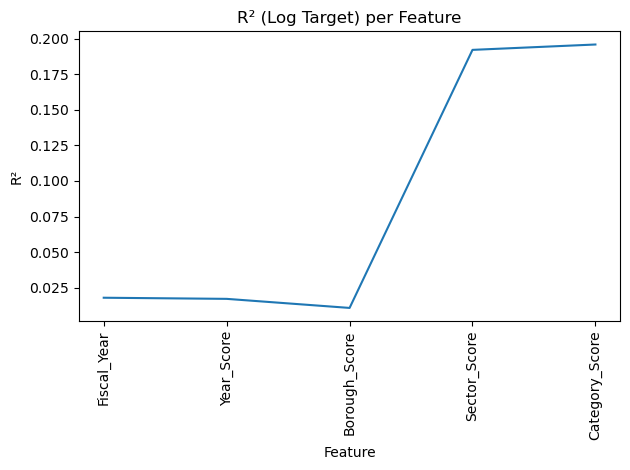

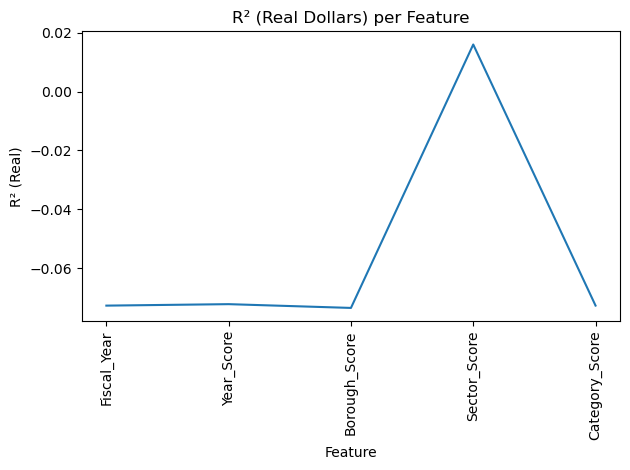

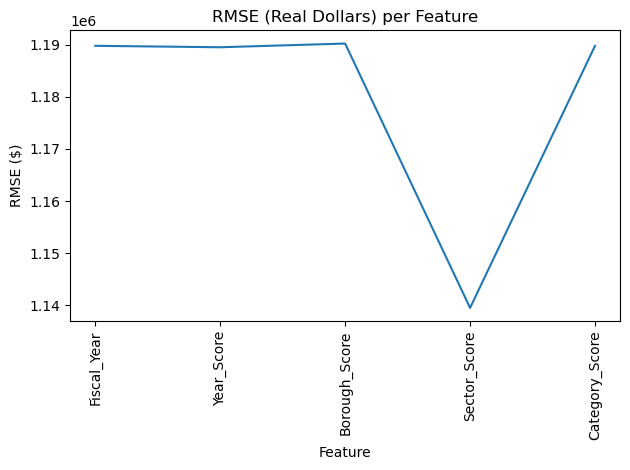

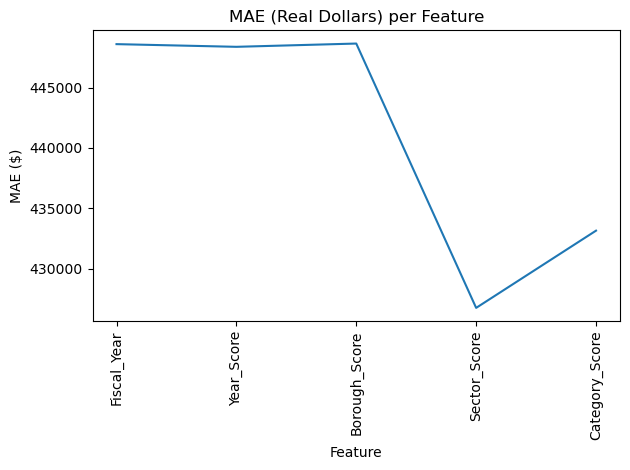

In [40]:
# R² (log target)
plt.figure()
plt.plot(features_list, r2_list)
plt.xticks(rotation=90)
plt.title("R² (Log Target) per Feature")
plt.xlabel("Feature")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

# R² (real dollars)
plt.figure()
plt.plot(features_list, r2_real_list)
plt.xticks(rotation=90)
plt.title("R² (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("R² (Real)")
plt.tight_layout()
plt.show()

# RMSE (real dollars)
plt.figure()
plt.plot(features_list, rmse_real_list)
plt.xticks(rotation=90)
plt.title("RMSE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("RMSE ($)")
plt.tight_layout()
plt.show()

# MAE (real dollars)
plt.figure()
plt.plot(features_list, mae_real_list)
plt.xticks(rotation=90)
plt.title("MAE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("MAE ($)")
plt.tight_layout()
plt.show()

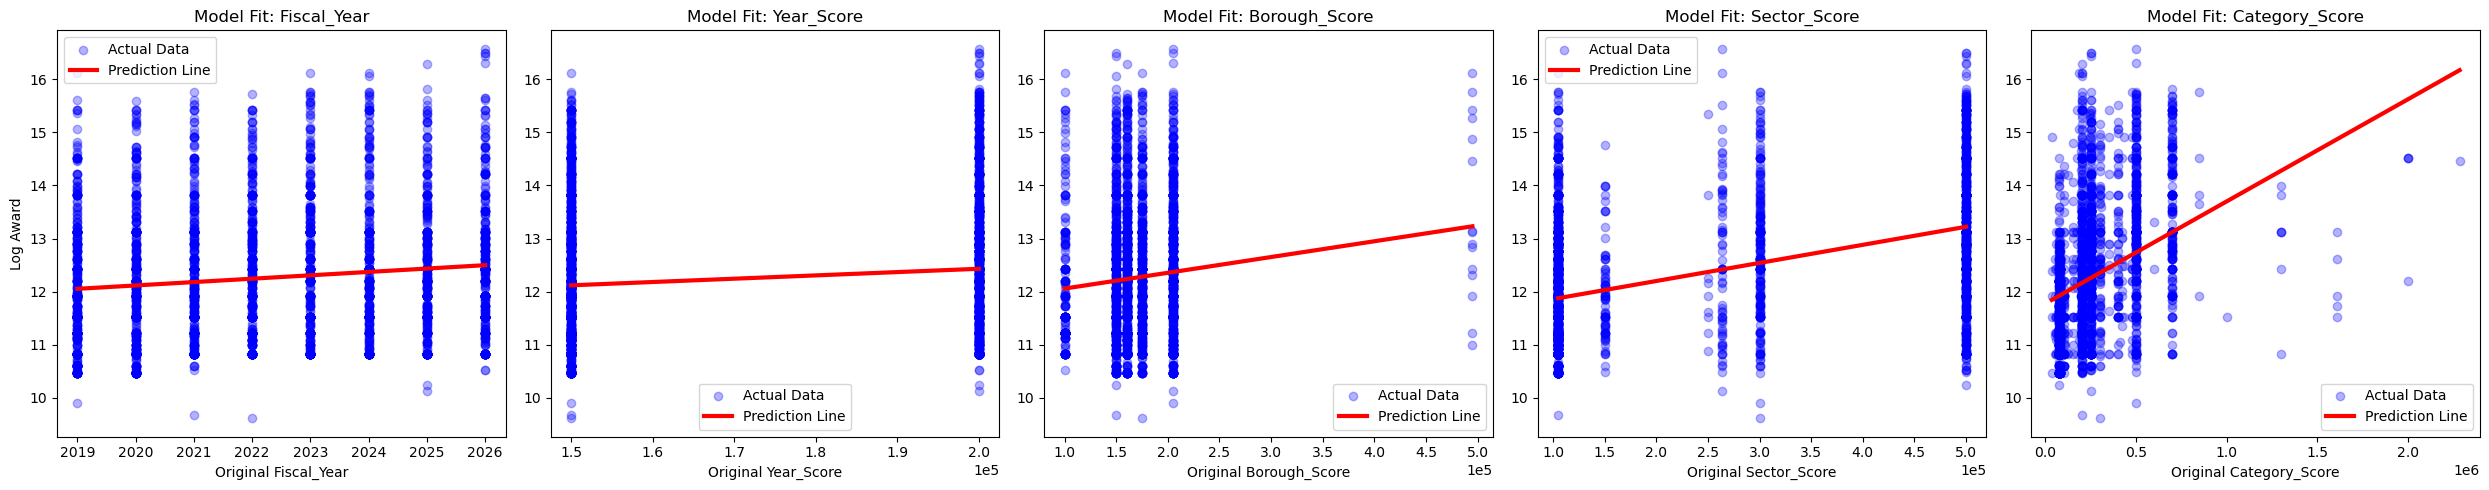

In [41]:
num_features = len(X_train_scaled.columns)
fig, axs = plt.subplots(nrows=1, ncols=num_features, figsize=(5 * num_features, 5))


# If you only have 1 feature, axs might not be an array. We handle that here:
if num_features == 1:
    axs = [axs]

for i, feature in enumerate(X_train_scaled.columns):
    
    # 1. Train and Predict using the SCALED data (The model needs this)
    lin_reg_scratch.fit(X_train_scaled[[feature]], y_train_reshaped)
    y_pred = lin_reg_scratch.predict(X_test_scaled[[feature]])
    
    # 2. Extract the ORIGINAL unscaled test data for the X-axis
    X_original = X_test[feature].values
    
    # 3. Sort the data! 
    # If we don't sort the original X values from smallest to largest, 
    # plt.plot will draw a chaotic zigzag connecting the random points.
    sorted_indices = np.argsort(X_original)
    X_original_sorted = X_original[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # 4. Plot using the ORIGINAL X values, but the PREDICTED Y values
    axs[i].scatter(X_original, y_test_reshaped, color='blue', alpha=0.3, label='Actual Data')
    axs[i].plot(X_original_sorted, y_pred_sorted, color='red', linewidth=3, label='Prediction Line')
    
    # 5. Formatting
    axs[i].set_title(f"Model Fit: {feature}")
    axs[i].set_xlabel(f"Original {feature}") # Now this labels it as original!
    axs[i].ticklabel_format(style='sci', axis='x', scilimits=(0, 5))
    
    if i == 0:
        axs[i].set_ylabel("Log Award")
        
    axs[i].legend()

plt.tight_layout()
plt.show()

In [42]:
# Using sklearn lib
lin_reg = LinearRegression()

features_list = []
r2_list = []
r2_real_list = []
rmse_real_list = []
mae_real_list = []

#for loop to use all features for regression
for feature in X_train_scaled:

    lin_reg.fit(X_train_scaled[[feature]], y_train_reshaped)

    intercept_lib = lin_reg.intercept_
    coefficient_lib = lin_reg.coef_

    #Formatting
    print(f"Feature used = {feature}")
    print(f"Intercept : {intercept_lib.ravel()[0]}")
    print(f"Coef : {coefficient_lib.ravel()[0]}")

    # y_pred_lib = lin_reg.predict(X_test_scaled[[feature]])

    # #Evaluation Metrics
    # mse_lib = mean_squared_error(y_test_reshaped, y_pred_lib)
    # mae_lib = mean_absolute_error(y_test_reshaped, y_pred_lib)
    # r2_lib = r2_score(y_test_reshaped, y_pred_lib)

    y_pred = lin_reg.predict(X_test_scaled[[feature]])
    y_test_real = np.exp(y_test_reshaped)
    y_pred_real = np.exp(y_pred)

    #Evaluation Metrics
    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    features_list.append(feature)
    r2_list.append(r2)
    r2_real_list.append(r2_real)
    rmse_real_list.append(rmse_real)
    mae_real_list.append(mae_real)


    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Feature used = Fiscal_Year
Intercept : 12.261321288640694
Coef : 0.14550456835177478
R^2: 0.01794311357520295 | R^2 (real): -0.07272257793033421 | RMSE (real): $1,189,771.86 | MAE (real): $448,588.79

Feature used = Year_Score
Intercept : 12.261321288640692
Coef : 0.15542619072909294
R^2: 0.017148482338880444 | R^2 (real): -0.07222446035652408 | RMSE (real): $1,189,495.59 | MAE (real): $448,366.78

Feature used = Borough_Score
Intercept : 12.261321288640692
Coef : 0.10186967172615144
R^2: 0.010776262030084638 | R^2 (real): -0.0735048833420977 | RMSE (real): $1,190,205.61 | MAE (real): $448,637.10

Feature used = Sector_Score
Intercept : 12.261321288640692
Coef : 0.5694846512655414
R^2: 0.19216003653887614 | R^2 (real): 0.01597052519846165 | RMSE (real): $1,139,525.47 | MAE (real): $426,770.56

Feature used = Category_Score
Intercept : 12.261321288640692
Coef : 0.5247678634203331
R^2: 0.19593250280075225 | R^2 (real): -0.07270655094941736 | RMSE (real): $1,189,762.97 | MAE (real): $433,

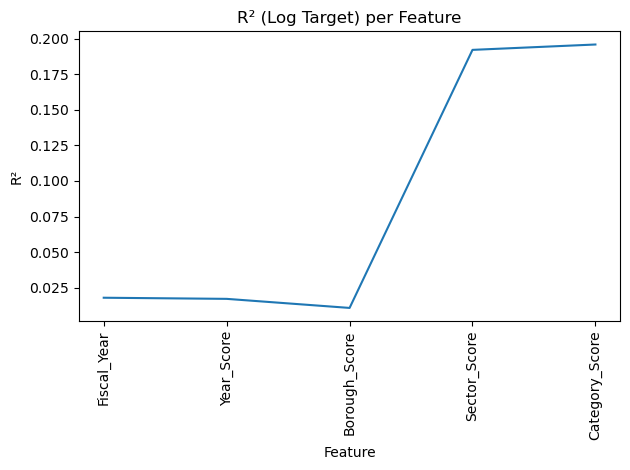

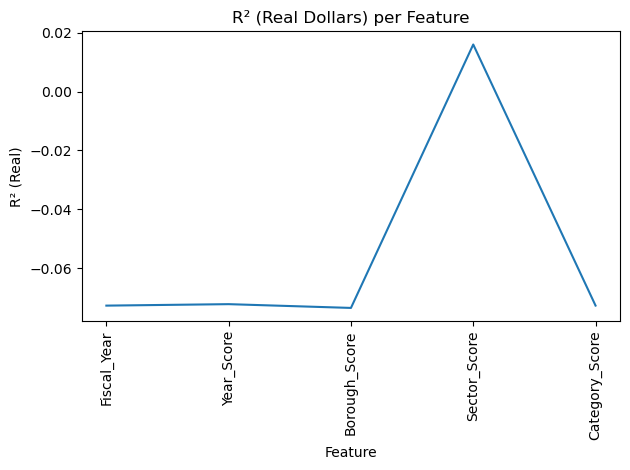

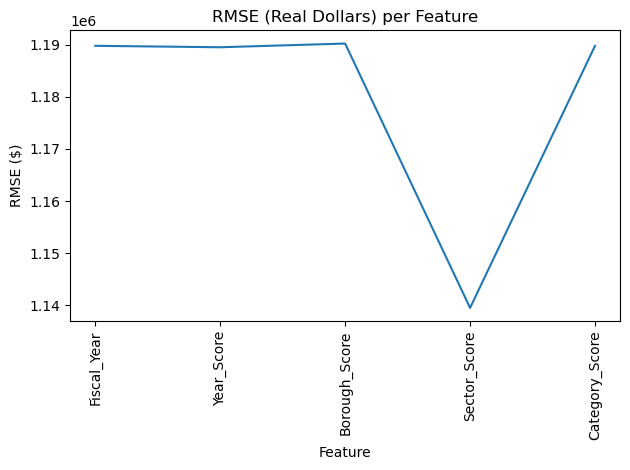

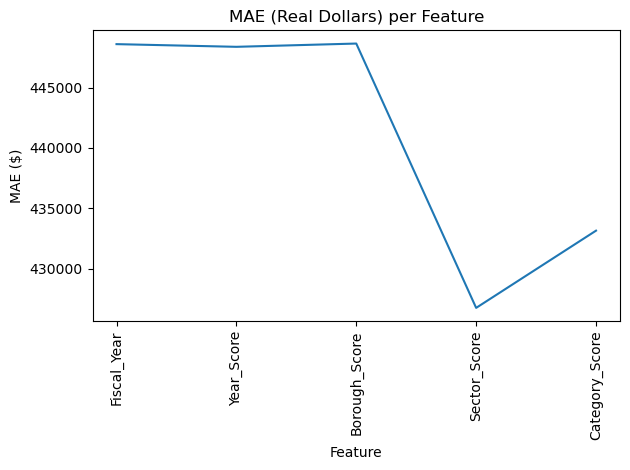

In [43]:
# R² (log target)
plt.figure()
plt.plot(features_list, r2_list)
plt.xticks(rotation=90)
plt.title("R² (Log Target) per Feature")
plt.xlabel("Feature")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

# R² (real dollars)
plt.figure()
plt.plot(features_list, r2_real_list)
plt.xticks(rotation=90)
plt.title("R² (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("R² (Real)")
plt.tight_layout()
plt.show()

# RMSE (real dollars)
plt.figure()
plt.plot(features_list, rmse_real_list)
plt.xticks(rotation=90)
plt.title("RMSE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("RMSE ($)")
plt.tight_layout()
plt.show()

# MAE (real dollars)
plt.figure()
plt.plot(features_list, mae_real_list)
plt.xticks(rotation=90)
plt.title("MAE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("MAE ($)")
plt.tight_layout()
plt.show()

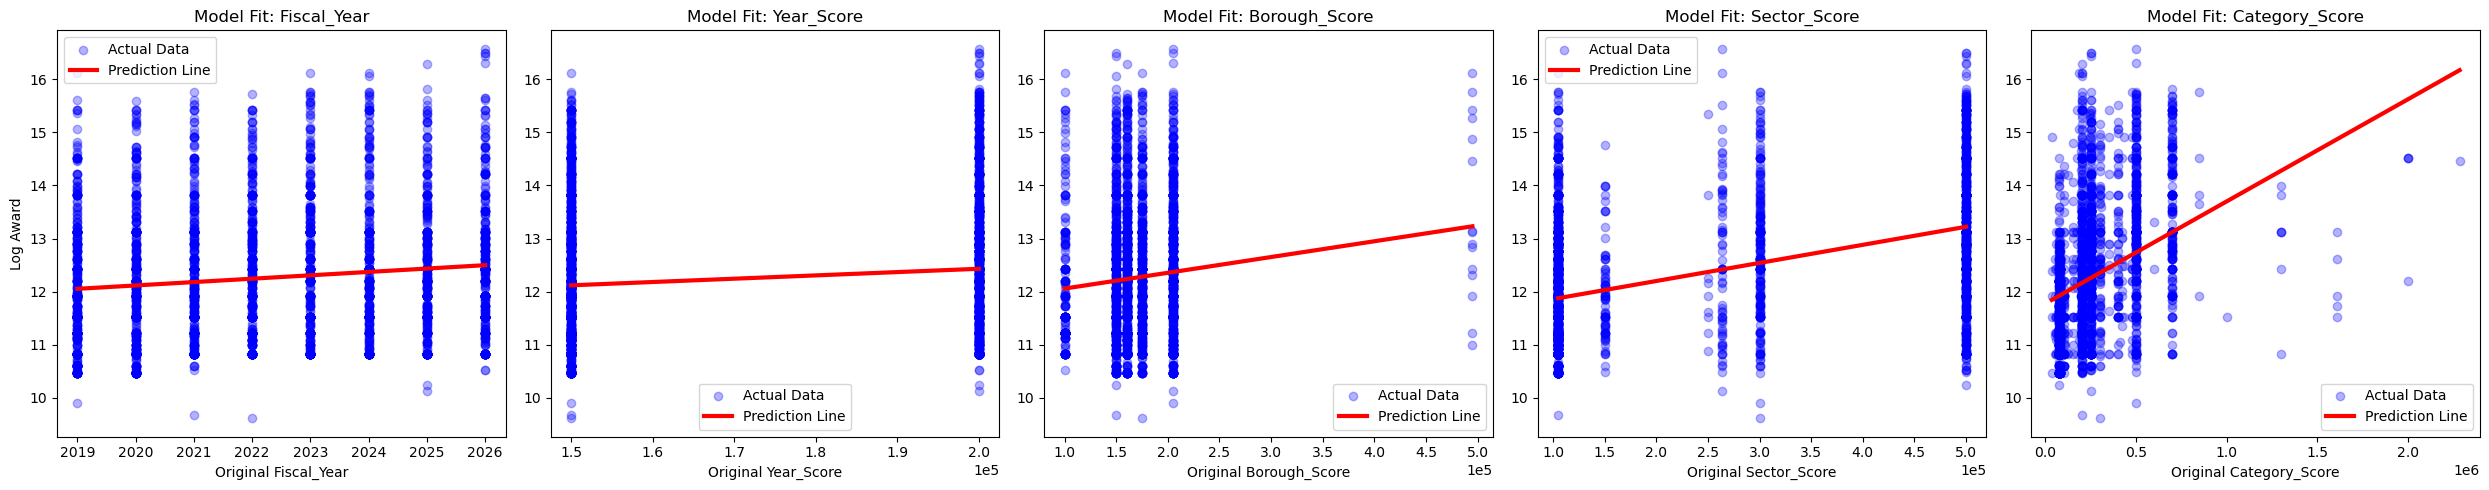

In [44]:
num_features = len(X_train_scaled.columns)
fig, axs = plt.subplots(nrows=1, ncols=num_features, figsize=(5 * num_features, 5))

# If you only have 1 feature, axs might not be an array. We handle that here:
if num_features == 1:
    axs = [axs]

for i, feature in enumerate(X_train_scaled.columns):
    
    # 1. Train and Predict using the SCALED data (The model needs this)
    lin_reg.fit(X_train_scaled[[feature]], y_train_reshaped)
    y_pred = lin_reg.predict(X_test_scaled[[feature]])
    
    # 2. Extract the ORIGINAL unscaled test data for the X-axis
    X_original = X_test[feature].values
    
    # 3. Sort the data! 
    # If we don't sort the original X values from smallest to largest, 
    # plt.plot will draw a chaotic zigzag connecting the random points.
    sorted_indices = np.argsort(X_original)
    X_original_sorted = X_original[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # 4. Plot using the ORIGINAL X values, but the PREDICTED Y values
    axs[i].scatter(X_original, y_test_reshaped, color='blue', alpha=0.3, label='Actual Data')
    axs[i].plot(X_original_sorted, y_pred_sorted, color='red', linewidth=3, label='Prediction Line')
    
    # 5. Formatting
    axs[i].set_title(f"Model Fit: {feature}")
    axs[i].set_xlabel(f"Original {feature}") # Now this labels it as original!
    axs[i].ticklabel_format(style='sci', axis='x', scilimits=(0, 5))
    
    if i == 0:
        axs[i].set_ylabel("Log Award")
        
    axs[i].legend()

plt.tight_layout()
plt.show()

Both result in not-so-ideal R2, MSE and MAE scores which is to be expected.

==========

Multiple Linear Regression:

==========

- Multiple Regression using GLOBAL MEDIANS

In [45]:
model_multi_scratch = LinearRegressionScratch()
model_multi_scratch.fit(X_train_scaled, y_train_reshaped)

# y_pred_train = model_multi_scratch.predict(X_train_scaled)
# y_pred_test = model_multi_scratch.predict(X_test_scaled)

# print("Train R2:", model_multi_scratch.R_squared(y_train_reshaped, y_pred_train))
# print("Test R2:", model_multi_scratch.R_squared(y_test_reshaped, y_pred_test))
# print("Test MAE:", model_multi_scratch.MAE(y_test_reshaped, y_pred_test))
# print("Test MSE:", model_multi_scratch.MSE(y_test_reshaped, y_pred_test))

y_pred = model_multi_scratch.predict(X_test_scaled)
y_test_real = np.exp(y_test_reshaped)
y_pred_real = np.exp(y_pred)

#Evaluation Metrics
r2 = model_multi_scratch.R_squared(y_test_reshaped, y_pred)
r2_real = model_multi_scratch.R_squared(y_test_real, y_pred_real)
mse_real = model_multi_scratch.MSE(y_test_real, y_pred_real)
mae_real = model_multi_scratch.MAE(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')




R^2: 0.28659760937233114 | R^2 (real): 0.034274806343494 | RMSE (real): $1,128,877.36 | MAE (real): $416,802.24



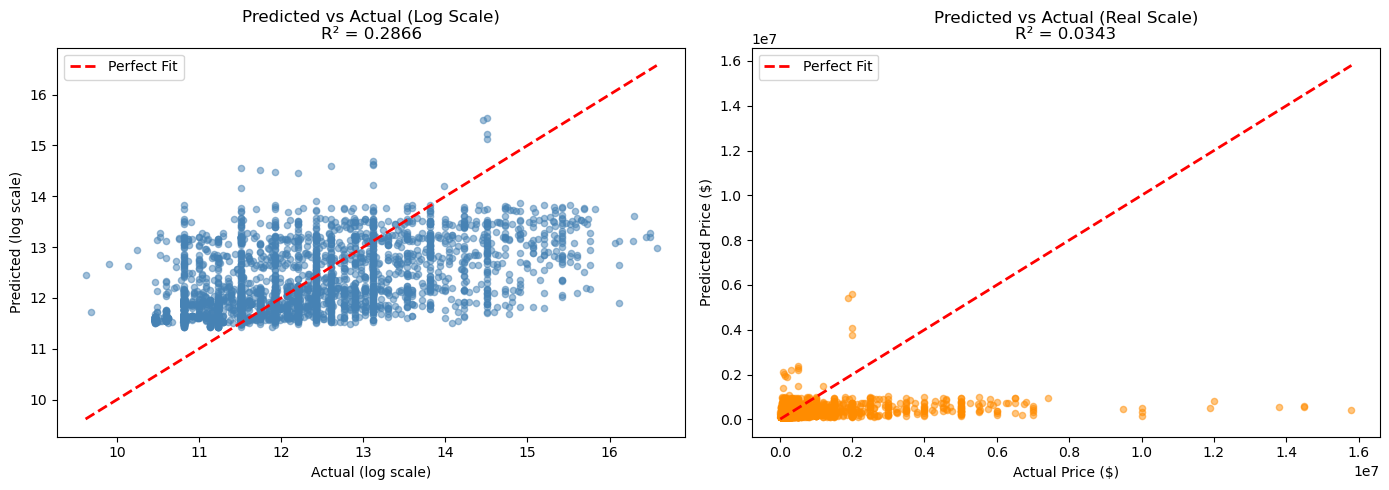

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale space
axes[0].scatter(y_test_reshaped, y_pred, alpha=0.5, color='steelblue', s=20)
min_val, max_val = min(y_test_reshaped.min(), y_pred.min()), max(y_test_reshaped.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual (log scale)')
axes[0].set_ylabel('Predicted (log scale)')
axes[0].set_title(f'Predicted vs Actual (Log Scale)\nR² = {r2:.4f}')
axes[0].legend()

# Real-scale space
axes[1].scatter(y_test_real, y_pred_real, alpha=0.5, color='darkorange', s=20)
min_val, max_val = min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Predicted vs Actual (Real Scale)\nR² = {r2_real:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

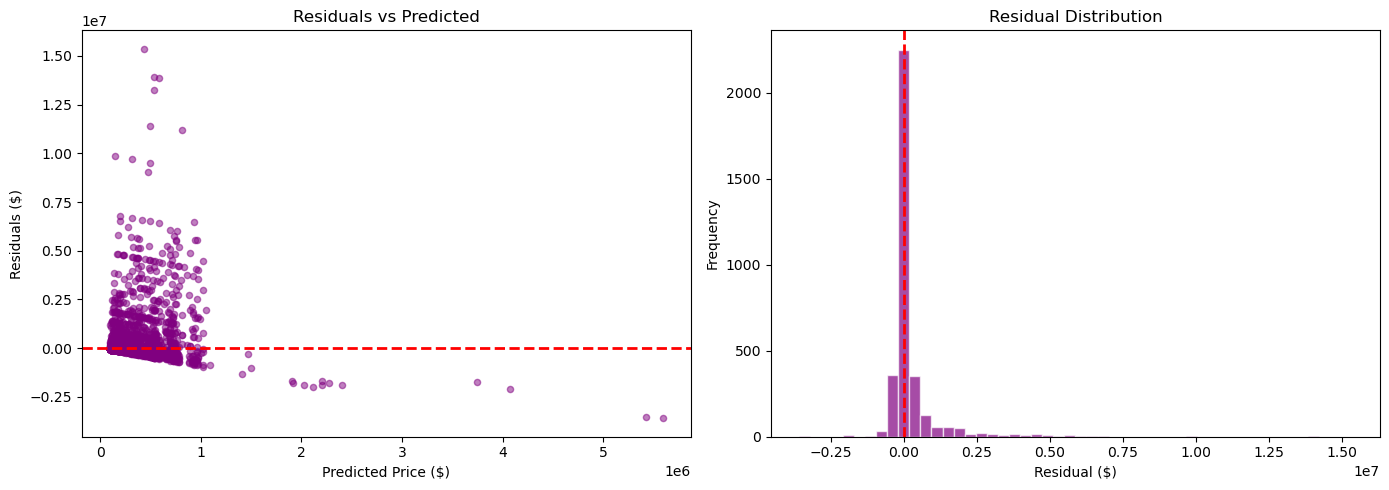

In [47]:
residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_real, residuals, alpha=0.5, color='purple', s=20)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Predicted')

# Residual Distribution
axes[1].hist(residuals, bins=50, color='purple', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

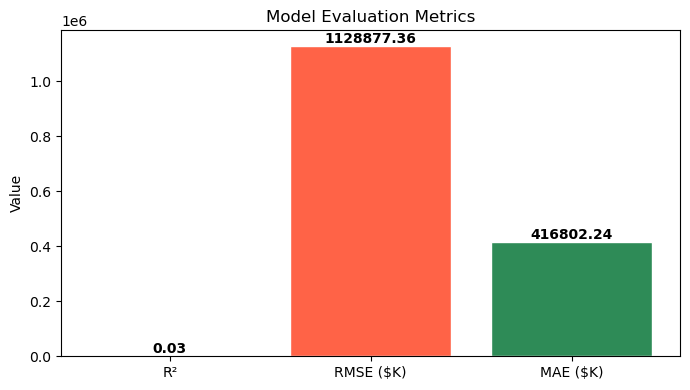

In [48]:
metrics = {'R²': r2_real, 'RMSE ($K)': rmse_real, 'MAE ($K)': mae_real}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(), color=['steelblue', 'tomato', 'seagreen'], edgecolor='white')

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Model Evaluation Metrics')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

In [49]:
# using sklearn lib
model_multi = LinearRegression()
model_multi.fit(X_train_scaled,y_train_reshaped)

# y_pred_train_2 = model_multi.predict(X_train_scaled)
# y_pred_test_2 = model_multi.predict(X_test_scaled)

# print("Train R2:", r2_score(y_train_reshaped, y_pred_train_2))
# print("Test R2:", r2_score(y_test_reshaped, y_pred_test_2))
# print("Test MAE:", mean_absolute_error(y_test_reshaped, y_pred_test_2))
# print("Test MSE:", mean_squared_error(y_test_reshaped, y_pred_test_2))

y_pred = model_multi.predict(X_test_scaled)
y_test_real = np.exp(y_test_reshaped)
y_pred_real = np.exp(y_pred)

#Evaluation Metrics
r2 = r2_score(y_test_reshaped, y_pred)
r2_real = r2_score(y_test_real, y_pred_real)
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')


R^2: 0.2865811209419511 | R^2 (real): 0.03428542720329841 | RMSE (real): $1,128,871.15 | MAE (real): $416,802.58



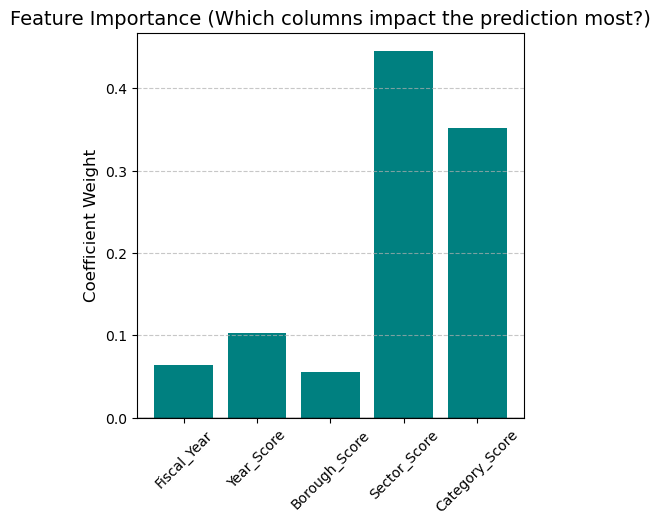

In [50]:
# Plotting Feature Importance (Coefficients)
plt.figure(figsize=(5, 5))

# Get feature names from the Pandas dataframe and flatten the coefficients array
feature_names = X_train_scaled.columns
coefficients = model_multi_scratch.coef_.flatten()

# Create a bar chart
plt.bar(feature_names, coefficients, color='teal')
plt.title('Feature Importance (Which columns impact the prediction most?)', fontsize=14)
plt.ylabel('Coefficient Weight', fontsize=12)
plt.axhline(y=0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

- Multiple Regression using FEATURE-BASED MEDIANS

In [51]:
# # 1. Splitting
# X = df.drop(['Award', 'log_Awards'], axis=1)
# y = df['log_Awards']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 2. Target Encoding
# # We use the raw Award from training to find the medians
# train_temp = X_train.copy()
# train_temp['Award'] = np.expm1(y_train) # Get original award back for medians

# # year_med = train_temp.groupby('Fiscal_Year')['Award'].median().reset_index().rename(columns={'Award': 'Year_Score'})
# borough_year_med = train_temp.groupby(['Fiscal_Year', 'Borough'])['Award'].median().reset_index().rename(columns={'Award': 'Boroughyear_Score'})
# sector_year_med = train_temp.groupby(['Fiscal_Year', 'Sector'])['Award'].median().reset_index().rename(columns={'Award': 'Sectoryear_Score'})
# category_year_med = train_temp.groupby(['Fiscal_Year', 'Category'])['Award'].median().reset_index().rename(columns={'Award': 'Categoryyear_Score'})

# # 2. Merge them into X_train
# # X_train = X_train.merge(year_med, on='Fiscal_Year', how='left')
# X_train = X_train.merge(borough_year_med, on=['Fiscal_Year', 'Borough'], how='left')
# X_train = X_train.merge(sector_year_med, on=['Fiscal_Year', 'Sector'], how='left')
# X_train = X_train.merge(category_year_med, on=['Fiscal_Year', 'Category'], how='left')

# # 3. Merge them into X_test
# # X_test = X_test.merge(year_med, on='Fiscal_Year', how='left')
# X_test = X_test.merge(borough_year_med, on=['Fiscal_Year', 'Borough'], how='left')
# X_test = X_test.merge(sector_year_med, on=['Fiscal_Year', 'Sector'], how='left')
# X_test = X_test.merge(category_year_med, on=['Fiscal_Year', 'Category'], how='left')

# # 4. Fill gaps using the Global Median
# global_med = train_temp['Award'].median()
# score_cols = ['Boroughyear_Score', 'Sectoryear_Score', 'Categoryyear_Score']
# X_train[score_cols] = X_train[score_cols].fillna(global_med)
# X_test[score_cols] = X_test[score_cols].fillna(global_med)

# # Dropping unnecessary columns
# to_drop = ['Borough', 'Council_District_num', 'Category', 'Sector']
# X_train.drop(columns=to_drop, inplace=True)
# X_test.drop(columns=to_drop, inplace=True)

# # Ensure both have same columns (if a borough was missing in test)
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# # --- 5. SCALING ---
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [52]:
# using Scratch Class
# y_train_array = y_train.values.reshape(-1, 1)
# y_test_array = y_test.values.reshape(-1, 1)

# model_multi_scratch = LinearRegressionScratch()
# model_multi_scratch.fit(X_train_scaled, y_train_array)

# y_pred_train = model_multi_scratch.predict(X_train_scaled)
# y_pred_test = model_multi_scratch.predict(X_test_scaled)

# print("Train R2:", model_multi_scratch.R_squared(y_train_array, y_pred_train))
# print("Test R2:", model_multi_scratch.R_squared(y_test_array, y_pred_test))
# print("Test MAE:", model_multi_scratch.MAE(y_test_array, y_pred_test))
# print("Test MSE:", model_multi_scratch.MSE(y_test_array, y_pred_test))


In [53]:
# using sklearn lib
# model_multi = LinearRegression()
# model_multi.fit(X_train_scaled,y_train_array)

# y_pred_train_2 = model_multi.predict(X_train_scaled)
# y_pred_test_2 = model_multi.predict(X_test_scaled)

# print("Train R2:", r2_score(y_train_array, y_pred_train_2))
# print("Test R2:", r2_score(y_test_array, y_pred_test_2))
# print("Test MAE:", mean_absolute_error(y_test_array, y_pred_test_2))
# print("Test MSE:", mean_squared_error(y_test_array, y_pred_test_2))


- The Feature-Based Median section results in worse overall evaluation scores, so we'll stick with the GLOBAL MEDIAN method.
- Council_District is no longer considered due to its extremely varied data entries.

Using sklearn lib:


==========

Polynomial Regression:

==========

- Polynomial Regression with all Feature Combinations (independent variables and mulitple independent variables)
- Using same data split as multiple linear regression (global medians included)

In [54]:
for d in range(1, 6):
    model_poly = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])
    
    model_poly.fit(X_train, y_train_reshaped)
    
    print(f"Degree {d}")

    y_pred = model_poly.predict(X_test)
    y_test_real = np.exp(y_test_reshaped)
    y_pred_real = np.exp(y_pred)

    #Evaluation Metrics
    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Degree 1
R^2: 0.2865811209419511 | R^2 (real): 0.0342854272032983 | RMSE (real): $1,128,871.15 | MAE (real): $416,802.58

Degree 2
R^2: 0.31751875851588607 | R^2 (real): -0.09746993943245652 | RMSE (real): $1,203,417.43 | MAE (real): $419,445.53

Degree 3
R^2: 0.3392169344009943 | R^2 (real): 0.06796941088840114 | RMSE (real): $1,109,008.99 | MAE (real): $405,474.87

Degree 4
R^2: 0.33721923415098476 | R^2 (real): -197.00772497080033 | RMSE (real): $16,164,454.35 | MAE (real): $681,272.98

Degree 5
R^2: 0.3245558121166312 | R^2 (real): -2689.8949852981996 | RMSE (real): $59,589,310.01 | MAE (real): $1,481,443.03



- Individual Polynomial Regression (From Scratch)

In [55]:
class PolyRegressionScratch:

    def __init__(self, degree=2, learning_rate=0.01, n_iterations=1000):
        self.degree = degree
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        
        self.coef_ = None
        self.intercept_ = None
        
        # New attributes to store scaling parameters
        self.feature_means_ = None
        self.feature_stds_ = None

    def _polynomial_features(self, X):
        X_poly = X.copy()

        # Add higher degree terms
        for d in range(2, self.degree + 1):
            X_poly = np.concatenate((X_poly, X ** d), axis=1)
        
        return X_poly

    def _scale_features(self, X_poly, is_training=False):
        if is_training:
            self.feature_means_ = np.mean(X_poly, axis=0)
            # Add 1e-8 to prevent division by zero in case of constant features
            self.feature_stds_ = np.std(X_poly, axis=0) + 1e-8
            
        return (X_poly - self.feature_means_) / self.feature_stds_
    
    def fit(self, X, y):
        X = np.array(X)  # handle DataFrames
        y = np.array(y)

        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=True)
        
        m, n_features = X_poly_scaled.shape
        
        self.coef_ = np.zeros((n_features, 1))
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X_poly_scaled, self.coef_) + self.intercept_
            residuals = y_pred - y

            intercept_gradient = (2/m) * np.sum(residuals)
            coef_gradient = (2/m) * np.dot(X_poly_scaled.T, residuals)

            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

            # Early stop if gradients explode
            if np.any(np.isnan(self.coef_)) or np.any(np.isinf(self.coef_)):
                print(f"Warning: Divergence detected, stopping early at iteration {_}")
                break

    def predict(self, X):
        X = np.array(X)  # handle DataFrames
        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=False)
        return np.dot(X_poly_scaled, self.coef_) + self.intercept_

    def R_squared(self, y_true, y_pred):
        SSres = np.sum((y_true - y_pred)**2)
        SStot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (SSres/SStot)

    def MAE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum(np.abs(y_true - y_pred)) / n

    def MSE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum((y_true - y_pred)**2) / n

- X_test and X_train = a dataframe containing Fiscal_Year, Year_Score, Borough_Score, Sector_Score, Category_Score

In [56]:
# Assume learning rate and n_inter
lr = 0.001
n_iter = 10000

#for loop to use all features for regression
for degree in range (2, 6):
    poly_reg_scratch= PolyRegressionScratch(degree=degree, learning_rate=lr, n_iterations=n_iter)
    for feature in X_train:
        poly_reg_scratch.fit(X_train[[feature]], y_train_reshaped)

            #Formatting
        print(f"Degree {degree}")
        print(f"Feature used: {feature}")
        # print(f"Intercept: {poly_reg_scratch.intercept_}")
        # print(f"Coef: {poly_reg_scratch.coef_[0][0]}")

        y_pred = poly_reg_scratch.predict(X_test[[feature]])
        y_test_real = np.exp(y_test_reshaped)
        y_pred_real = np.exp(y_pred)

            #Evaluation Metrics
        r2 = poly_reg_scratch.R_squared(y_test_reshaped, y_pred)
        r2_real = poly_reg_scratch.R_squared(y_test_real, y_pred_real)
        mse_real = poly_reg_scratch.MSE(y_test_real, y_pred_real)
        mae_real = poly_reg_scratch.MAE(y_test_real, y_pred_real)
        rmse_real = np.sqrt(mse_real)

        print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')
  


Degree 2
Feature used: Fiscal_Year
R^2: 0.01794027230475892 | R^2 (real): -0.07272288451484377 | RMSE (real): $1,189,772.03 | MAE (real): $448,589.25

Degree 2
Feature used: Year_Score
R^2: 0.01714848297211391 | R^2 (real): -0.07222446301827001 | RMSE (real): $1,189,495.59 | MAE (real): $448,366.78

Degree 2
Feature used: Borough_Score
R^2: 0.010783283244261366 | R^2 (real): -0.07314475421342181 | RMSE (real): $1,190,005.96 | MAE (real): $448,706.80

Degree 2
Feature used: Sector_Score
R^2: 0.18990539312884913 | R^2 (real): 0.01521319412418054 | RMSE (real): $1,139,963.88 | MAE (real): $427,081.57

Degree 2
Feature used: Category_Score
R^2: 0.2297569188343639 | R^2 (real): -0.9087972598918235 | RMSE (real): $1,587,083.89 | MAE (real): $471,489.46

Degree 3
Feature used: Fiscal_Year
R^2: 0.017937437020946856 | R^2 (real): -0.07272318913576648 | RMSE (real): $1,189,772.20 | MAE (real): $448,589.70

Degree 3
Feature used: Year_Score
R^2: 0.01714848297211391 | R^2 (real): -0.07222446301827

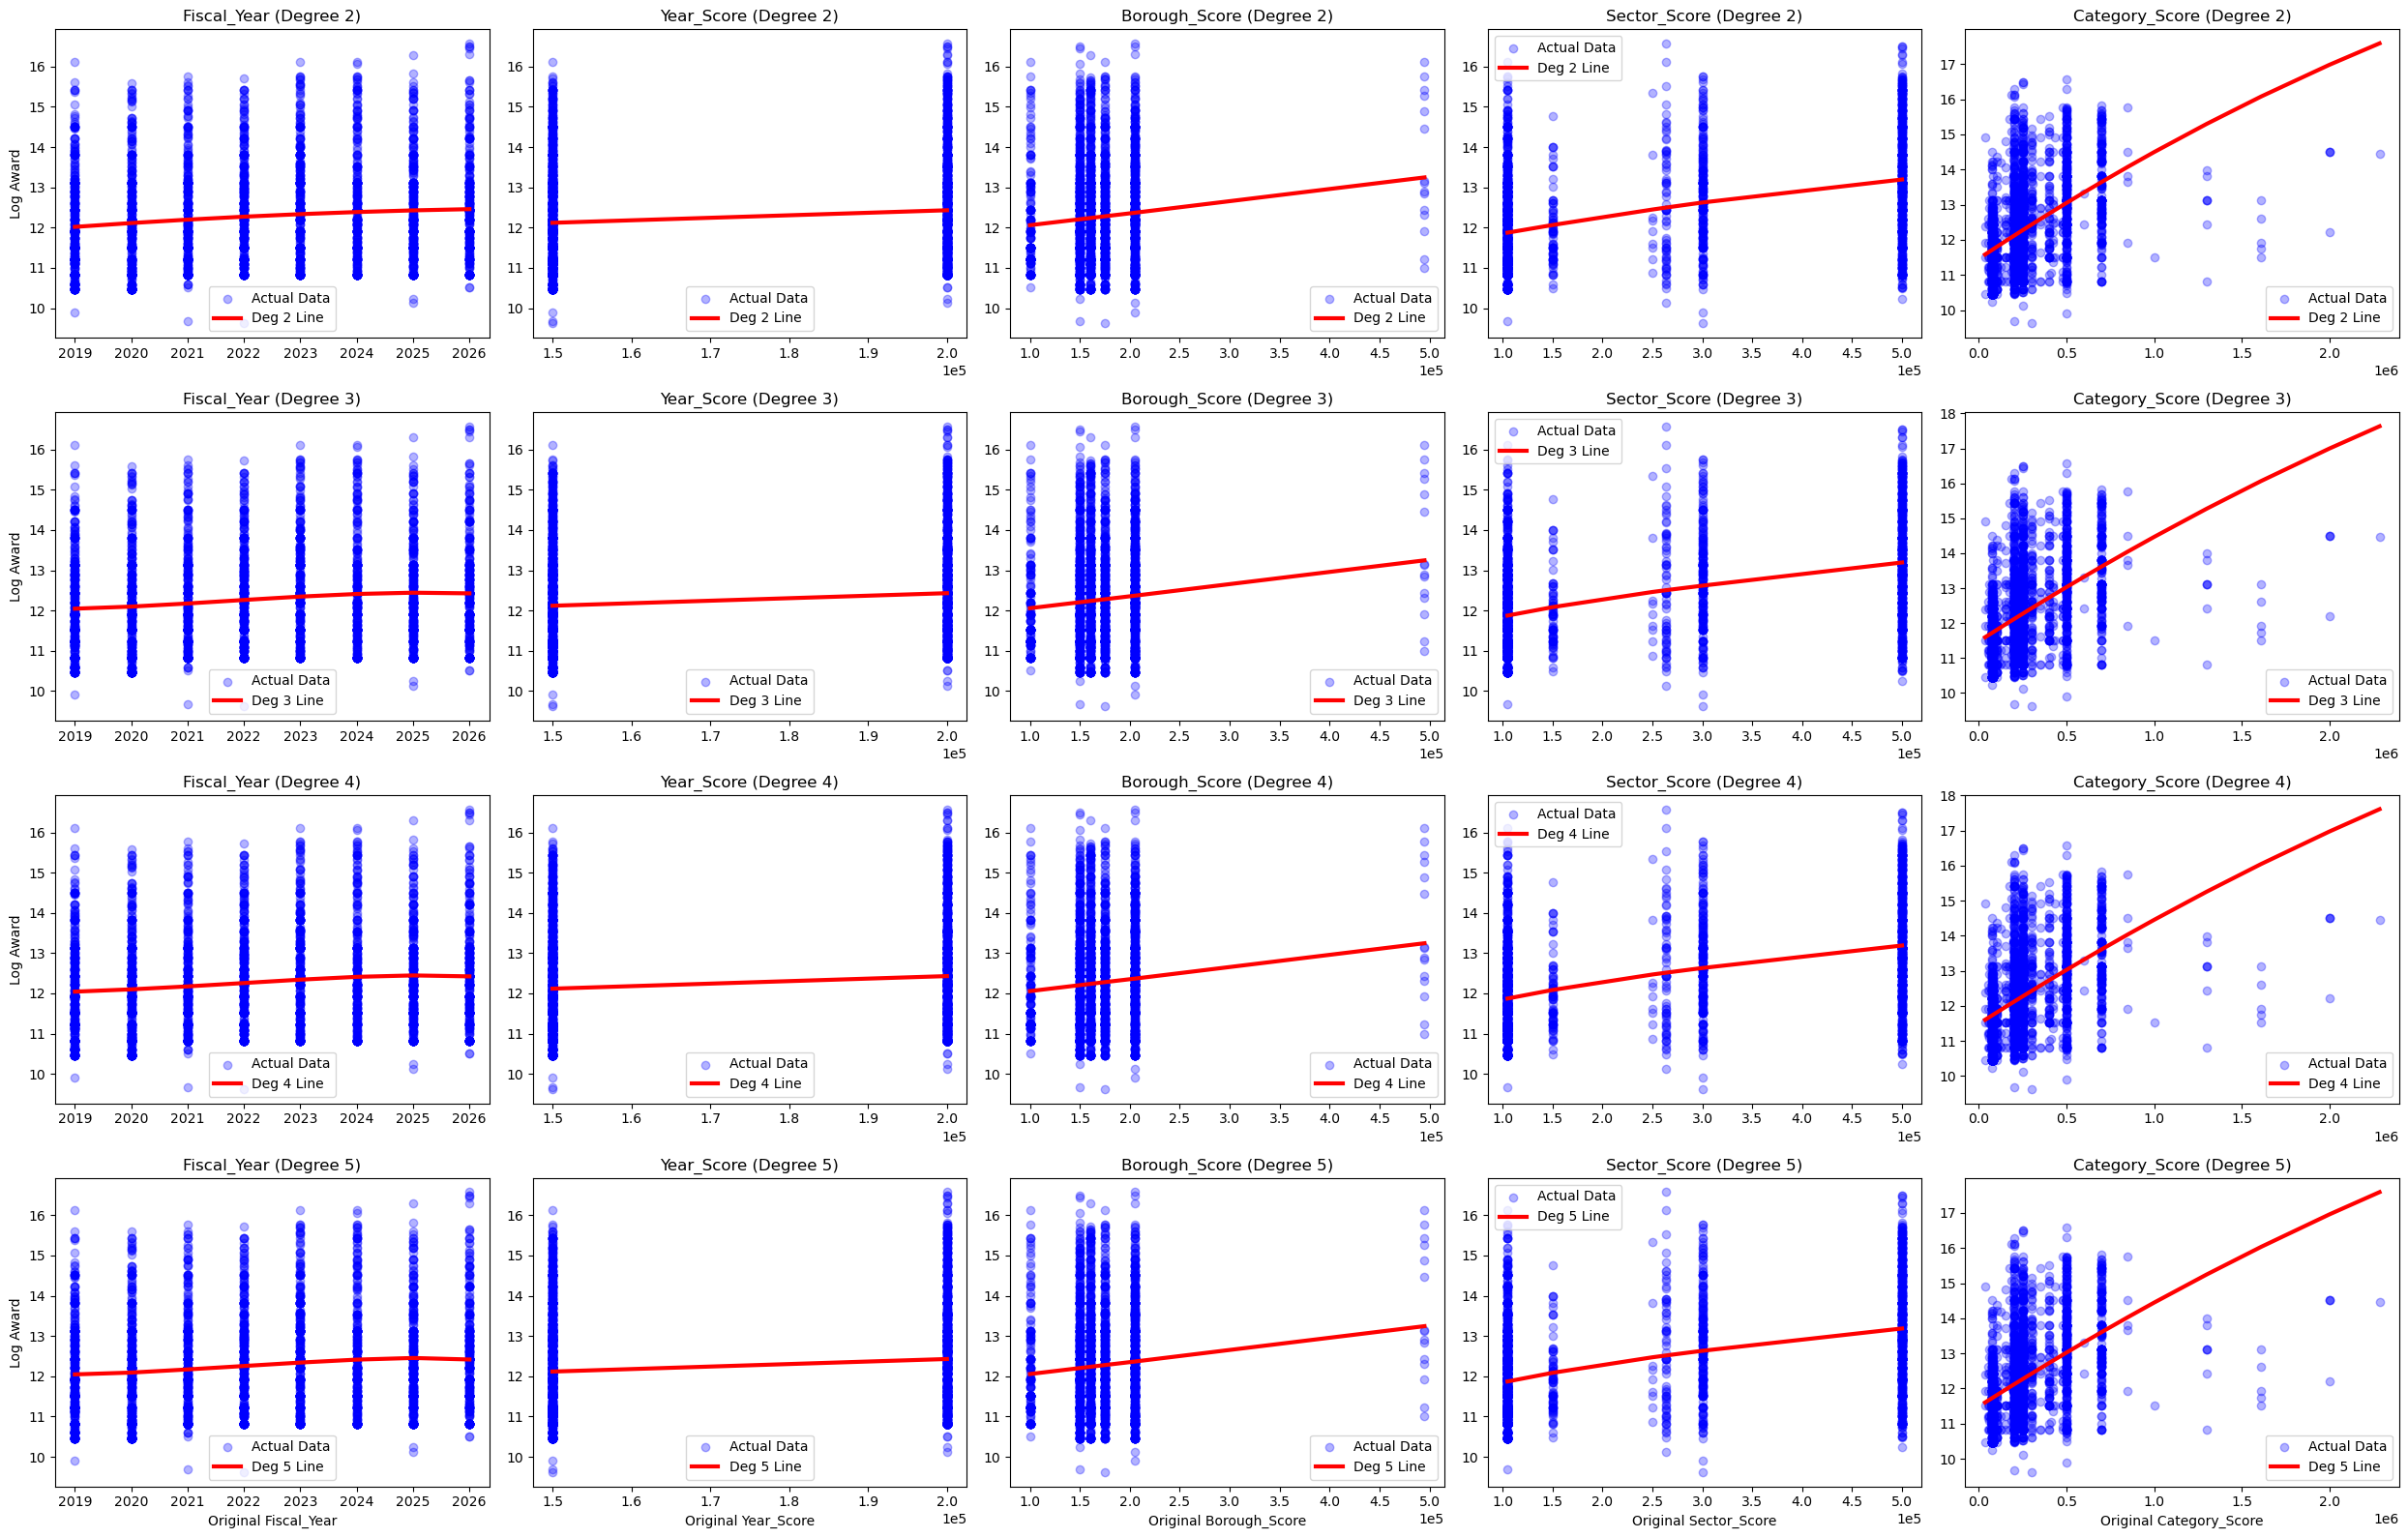

In [57]:
degrees = [2, 3, 4, 5] # The rows

num_degrees = len(degrees)
num_features = len(X_train_scaled.columns)

# Create the 2D grid of subplots (squeeze=False guarantees it stays a 2D array)
fig, axs = plt.subplots(nrows=num_degrees, ncols=num_features, 
                        figsize=(5 * num_features, 4 * num_degrees), 
                        squeeze=False)

for row_idx, degree in enumerate(degrees):
    for col_idx, feature in enumerate(X_train_scaled.columns):
        
        # Select the specific subplot for this Degree + Feature combo
        ax = axs[row_idx, col_idx]
        
        # 1. Initialize and Train the Polynomial Model
        poly_reg = PolyRegressionScratch(degree=degree, learning_rate=lr, n_iterations=n_iter)
        poly_reg.fit(X_train_scaled[[feature]], y_train_reshaped)
        
        # Predict on the scaled test data
        y_pred = poly_reg.predict(X_test_scaled[[feature]])
        
        # 2. Extract the ORIGINAL unscaled test data for the X-axis
        X_original = X_test[feature].values
        
        # 3. Sort the data! (CRITICAL FOR POLYNOMIALS)
        # If you don't sort a curve, Matplotlib will draw a massive scribble connecting the dots
        sorted_indices = np.argsort(X_original)
        X_original_sorted = X_original[sorted_indices]
        y_pred_sorted = y_pred[sorted_indices]
        
        # 4. Plot using the ORIGINAL X values, but the PREDICTED Y values
        ax.scatter(X_original, y_test_reshaped, color='blue', alpha=0.3, label='Actual Data')
        ax.plot(X_original_sorted, y_pred_sorted, color='red', linewidth=3, label=f'Deg {degree} Line')
        
        # 5. Formatting
        ax.set_title(f"{feature} (Degree {degree})")
        
        # Only put X labels on the very bottom row to keep it clean
        if row_idx == num_degrees - 1:
            ax.set_xlabel(f"Original {feature}")
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 5))
            
        # Only put Y labels on the far left column
        if col_idx == 0:
            ax.set_ylabel("Log Award")
            
        ax.legend()

plt.tight_layout()
plt.show()

In [58]:
# multiple polynomial regression

for d in range(2, 6):
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train, y_train_reshaped)
    
    print(f"Degree {d}")

    y_pred = multi_model_poly.predict(X_test)
    y_test_real = np.exp(y_test_reshaped)
    y_pred_real = np.exp(y_pred)

    #Evaluation Metrics
    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')


Degree 2
R^2: 0.3010505049317418 | R^2 (real): -0.09960171644591509 | RMSE (real): $1,204,585.65 | MAE (real): $430,460.15

Degree 3
R^2: 0.2999042732431376 | R^2 (real): -0.1221157543787239 | RMSE (real): $1,216,854.95 | MAE (real): $431,677.19

Degree 4
R^2: 0.30047109229958857 | R^2 (real): -0.11721515858755094 | RMSE (real): $1,214,194.87 | MAE (real): $431,105.33

Degree 5
R^2: 0.30111149340869636 | R^2 (real): -0.11051018062323559 | RMSE (real): $1,210,545.88 | MAE (real): $430,499.59



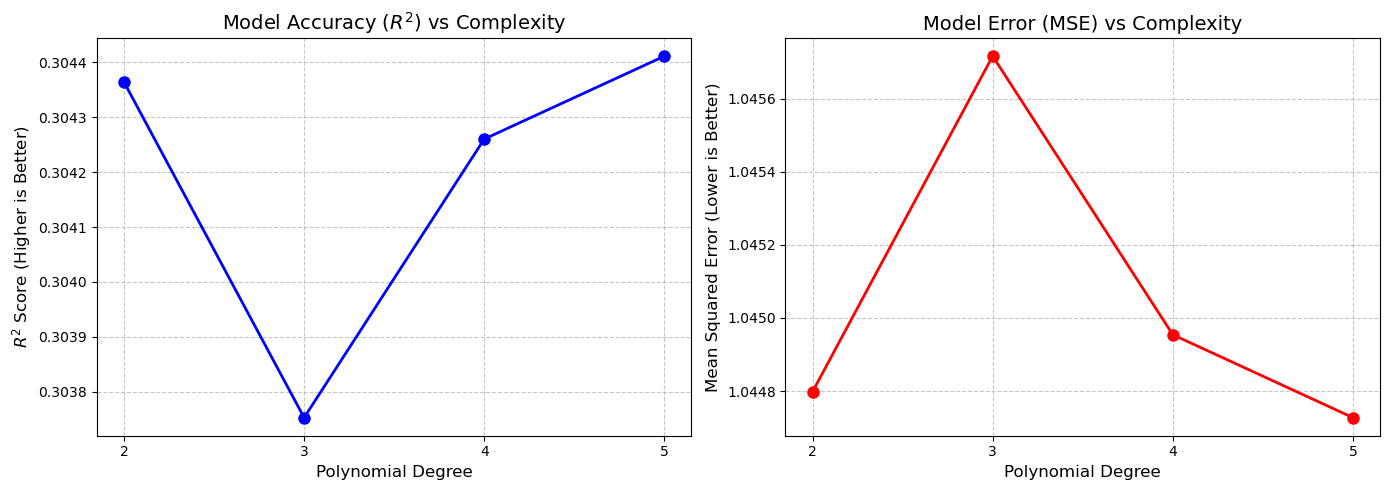

In [59]:
# 1. Create empty lists to save the scores
degrees = list(range(2, 6))
r2_scores = []
mse_scores = []

# 2. Run your exact same loop
for d in degrees:
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train_scaled, y_train_reshaped)
    multi_y_pred = multi_model_poly.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test_reshaped, multi_y_pred)
    r2 = r2_score(y_test_reshaped, multi_y_pred)
    
    # Save the metrics
    r2_scores.append(r2)
    mse_scores.append(mse)

# 3. Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R-Squared (Higher is better)
ax1.plot(degrees, r2_scores, marker='o', color='blue', linewidth=2, markersize=8)
ax1.set_title('Model Accuracy ($R^2$) vs Complexity', fontsize=14)
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('$R^2$ Score (Higher is Better)', fontsize=12)
ax1.set_xticks(degrees)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Mean Squared Error (Lower is better)
ax2.plot(degrees, mse_scores, marker='o', color='red', linewidth=2, markersize=8)
ax2.set_title('Model Error (MSE) vs Complexity', fontsize=14)
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('Mean Squared Error (Lower is Better)', fontsize=12)
ax2.set_xticks(degrees)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [60]:
from itertools import combinations_with_replacement

class PolyRegressionScratch:

    def __init__(self, degree=2, learning_rate=0.01, n_iterations=1000):
        self.degree = degree
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        
        self.coef_ = None
        self.intercept_ = None
        self.feature_means_ = None
        self.feature_stds_ = None

    def _polynomial_features(self, X):
        # Convert to numpy array just in case a DataFrame is passed in
        X = np.array(X)
        m, n = X.shape
        features = []

        for d in range(1, self.degree + 1):
            for combo in combinations_with_replacement(range(n), d):
                term = np.prod(X[:, list(combo)], axis=1, keepdims=True)
                features.append(term)

        return np.concatenate(features, axis=1)

    def _scale_features(self, X_poly, is_training=False):
        if is_training:
            self.feature_means_ = np.mean(X_poly, axis=0)
            self.feature_stds_ = np.std(X_poly, axis=0)
            # Replace near-zero stds with 1.0 instead of adding 1e-8
            self.feature_stds_[self.feature_stds_ < 1e-8] = 1.0
            
        return (X_poly - self.feature_means_) / self.feature_stds_

    def fit(self, X, y):
        X = np.array(X)  # handle DataFrames
        y = np.array(y)

        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=True)
        
        m, n_features = X_poly_scaled.shape
        
        self.coef_ = np.zeros((n_features, 1))
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X_poly_scaled, self.coef_) + self.intercept_
            residuals = y_pred - y

            intercept_gradient = (2/m) * np.sum(residuals)
            coef_gradient = (2/m) * np.dot(X_poly_scaled.T, residuals)

            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

            # Early stop if gradients explode
            if np.any(np.isnan(self.coef_)) or np.any(np.isinf(self.coef_)):
                print(f"Warning: Divergence detected, stopping early at iteration {_}")
                break

    def predict(self, X):
        X = np.array(X)  # handle DataFrames
        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=False)
        return np.dot(X_poly_scaled, self.coef_) + self.intercept_

    def R_squared(self, y_true, y_pred):
        SSres = np.sum((y_true - y_pred)**2)
        SStot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (SSres/SStot)

    def MAE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum(np.abs(y_true - y_pred)) / n

    def MSE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum((y_true - y_pred)**2) / n

In [61]:
X_train.values

array([[  2024., 199999., 159999., 104999., 199999.],
       [  2021., 149999., 204999., 104999., 199999.],
       [  2020., 149999., 149999., 499999., 499999.],
       ...,
       [  2022., 149999.,  99999., 104999.,  79999.],
       [  2019., 149999., 204999., 104999.,  74999.],
       [  2023., 199999., 204999., 299999., 299999.]])

In [62]:
lr = 0.001
n_iter = 10000

for d in range(2, 6):
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train, y_train_reshaped)
    
    print(f"Degree {d}")

    y_pred = multi_model_poly.predict(X_test)
    # y_pred_train = multi_model_poly.predict(X_train)  
    y_test_real = np.exp(y_test_reshaped)
    y_pred_real = np.exp(y_pred)

    # r2_train = r2_score(y_train_reshaped, y_pred_train)  # fixed
    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)

    # print(f'R^2 (train): {r2_train} | R^2 (test): {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')
    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Degree 2
R^2: 0.311520698852353 | R^2 (real): -0.04975840439549195 | RMSE (real): $1,176,968.02 | MAE (real): $419,891.74

Degree 3
R^2: 0.31450614346527983 | R^2 (real): -0.15399566519051366 | RMSE (real): $1,234,019.64 | MAE (real): $420,956.89

Degree 4
R^2: 0.31615064563767736 | R^2 (real): -0.03817634601257369 | RMSE (real): $1,170,457.23 | MAE (real): $417,272.50

Degree 5
R^2: 0.31961907824061975 | R^2 (real): 0.042715099804391254 | RMSE (real): $1,123,933.42 | MAE (real): $412,887.99



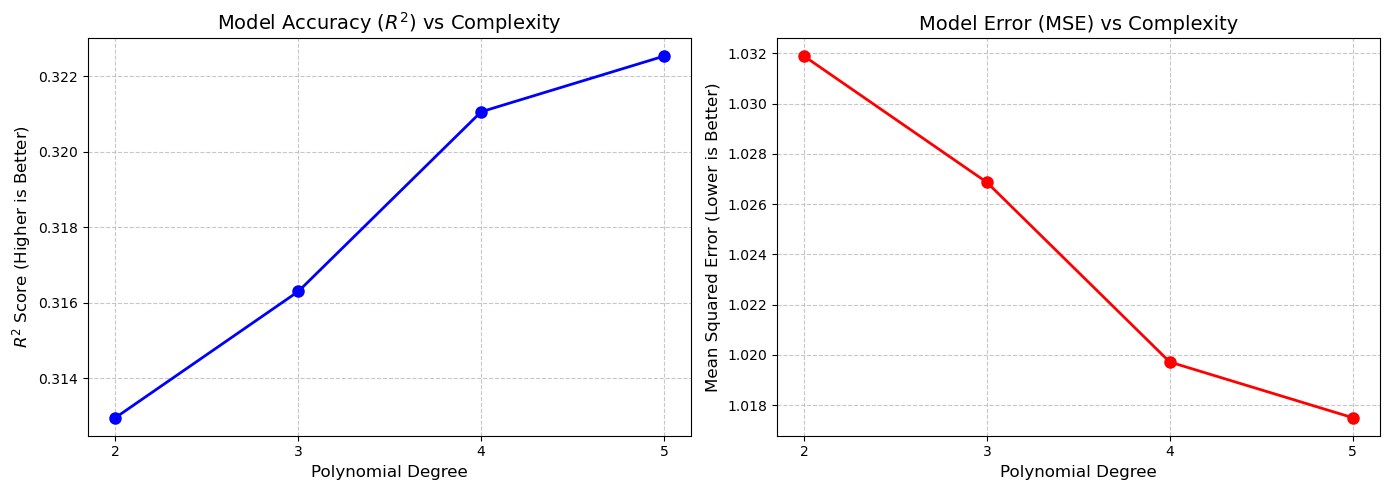

In [63]:
# 1. Create empty lists to save the scores
degrees = list(range(2, 6))
r2_scores = []
mse_scores = []

# 2. Run your exact same loop
for d in degrees:
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train_scaled, y_train_reshaped)
    multi_y_pred = multi_model_poly.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test_reshaped, multi_y_pred)
    r2 = r2_score(y_test_reshaped, multi_y_pred)
    
    # Save the metrics
    r2_scores.append(r2)
    mse_scores.append(mse)

# 3. Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R-Squared (Higher is better)
ax1.plot(degrees, r2_scores, marker='o', color='blue', linewidth=2, markersize=8)
ax1.set_title('Model Accuracy ($R^2$) vs Complexity', fontsize=14)
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('$R^2$ Score (Higher is Better)', fontsize=12)
ax1.set_xticks(degrees)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Mean Squared Error (Lower is better)
ax2.plot(degrees, mse_scores, marker='o', color='red', linewidth=2, markersize=8)
ax2.set_title('Model Error (MSE) vs Complexity', fontsize=14)
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('Mean Squared Error (Lower is Better)', fontsize=12)
ax2.set_xticks(degrees)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Testing other models

In [64]:
from sklearn.neural_network import MLPRegressor

model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(128,64),
                         activation='relu',
                         max_iter=1000,
                         alpha=0.001,
                         random_state=42))
])

# Train
model.fit(X_train, y_train)

# Predict (log space)
y_pred_log = model.predict(X_test)

# Convert back to real dollars
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

# Compute metrics in real scale
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_log = r2_score(y_test, y_pred_log)
r2_real = r2_score(y_test_real, y_pred_real)

print("R2 (log values):", r2_log)
print("R2 (real):", r2_real)
print("MAE (real):", mae_real)
print("RMSE (real):", np.sqrt(mse_real))


R2 (log values): 0.35074116772246167
R2 (real): 0.06713167258299968
MAE (real): 403401.2930213644
RMSE (real): 1109507.2800027353


In [65]:
from sklearn.ensemble import GradientBoostingRegressor

# After your existing preprocessing, add log-transformed scores:
for col in ['Year_Score', 'Borough_Score', 'Sector_Score', 'Category_Score']:
    X_train[f'log_{col}'] = np.log(X_train[col])
    X_test[f'log_{col}'] = np.log1p(X_test[col])

model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    min_samples_leaf=20,
    random_state=42
)


# Train
model.fit(X_train, y_train)

# Predict (log space)
y_pred_log = model.predict(X_test)

# Convert back to real dollars
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

# Compute metrics in real scale
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_log = r2_score(y_test, y_pred_log)
r2_real = r2_score(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2_log} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')



R^2: 0.3659376058120851 | R^2 (real): 0.08239074219490683 | RMSE (real): $1,100,395.68 | MAE (real): $399,623.79



Let's try a GradientBoostingRegressor scratch model from: https://www.kaggle.com/code/egazakharenko/gradient-boosting-from-scratch-full-tutorial/notebook

In [66]:
from sklearn.tree import DecisionTreeRegressor

class GBMRegressor:
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, random_state=0):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        self.initial_leaf = y.mean()
        predictions = np.zeros(len(y)) + self.initial_leaf

        for _ in range(self.n_estimators):
            residuals = y - predictions
            tree = DecisionTreeRegressor(criterion='friedman_mse', max_depth=self.max_depth,
                                         random_state=self.random_state)
            tree.fit(X, residuals)
            predictions += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, samples):
        predictions = np.zeros(len(samples)) + self.initial_leaf

        for i in range(self.n_estimators):
            predictions += self.learning_rate * self.trees[i].predict(samples)

        return predictions

In [67]:
model_new = GBMRegressor()
model_new.fit(X_train, y_train)

y_pred_log = model_new.predict(X_test)

# Convert back to real dollars
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

# Compute metrics in real scale
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_log = r2_score(y_test, y_pred_log)
r2_real = r2_score(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2_log} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

R^2: 0.36339412763123613 | R^2 (real): 0.08068587691213513 | RMSE (real): $1,101,417.44 | MAE (real): $400,211.75



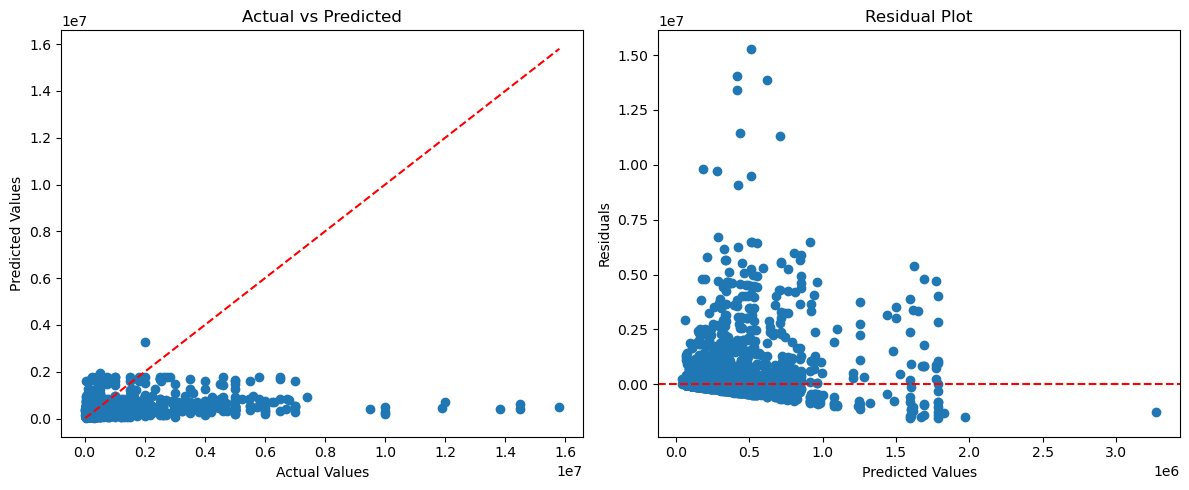

In [68]:
residuals = y_test_real - y_pred_real

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Plot 1: Actual vs Predicted
ax[0].scatter(y_test_real, y_pred_real)
ax[0].plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    color='red', linestyle="--"
)
ax[0].set_xlabel("Actual Values")
ax[0].set_ylabel("Predicted Values")
ax[0].set_title("Actual vs Predicted")

# Plot 2: Residuals
ax[1].scatter(y_pred_real, residuals)
ax[1].axhline(0, color='red', linestyle="--")
ax[1].set_xlabel("Predicted Values")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()